# Whisper-LoRA 繁體中文微調

本專案使用 **LoRA (Low-Rank Adaptation)** 技術對 Whisper 模型進行繁體中文語音辨識調 (Fine-tuning)  

* **基礎模型**：`openai/whisper-large-v2`
* **微調技術**：PEFT / LoRA
* **訓練資料集**：[Mozilla Common Voice 24.0 (Taiwan)](https://commonvoice.mozilla.org/)







## 匯入相關套件與資料

In [ ]:
import pandas as pd
from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tarfile
import os

tar_path = '/content/drive/MyDrive/Data/common voice zh-TW/cv-corpus-24.0-2025-12-05-zh-TW.tar.gz'
extracted_path = '/content/extracted_data'

with tarfile.open(tar_path, 'r:*') as tar:
    tar.extractall(extracted_path)

print(os.listdir(extracted_path))

/tmp/ipykernel_2104/2518420684.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extracted_path)


['cv-corpus-24.0-2025-12-05']


## 資料探勘與前處理

### 查看資料集

*   `path`：音訊檔案相對路徑
*   `sentence`：音訊對應之逐字稿文本
*   `up_votes` / `down_votes`：社群審核票數（可用於資料清洗與品質過濾）

> **提示**：基礎語音辨識（ASR）任務主要使用 `path` 與 `sentence` 兩個欄位即可完成模型訓練。

In [ ]:
from pathlib import Path

BASE_DIR = Path(extracted_path + '/' + 'cv-corpus-24.0-2025-12-05')
lang_dir = BASE_DIR / 'zh-TW'
clips_dir = lang_dir / 'clips'
train_path = lang_dir / 'train.tsv'

df_train = pd.read_csv(train_path, sep = '\t')
df_train.head()

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
0,301cf15bd7aefefb9a060797d4ea37574efccebade7902...,common_voice_zh-TW_17421058.mp3,789b2e1f58662faafd19bffdb048ee5e2db87d6b73f968...,一家搬往台北蘆洲,NaN,2,0,thirties,male_masculine,NaN,NaN,zh-TW,NaN
1,301cf15bd7aefefb9a060797d4ea37574efccebade7902...,common_voice_zh-TW_17421060.mp3,2c5c08408b9ddc629de0ea27e63af35c86593335587f63...,我們也感同身受,NaN,2,0,thirties,male_masculine,NaN,NaN,zh-TW,NaN
2,301cf15bd7aefefb9a060797d4ea37574efccebade7902...,common_voice_zh-TW_17421089.mp3,14e9f30b862049e196bd382ccfec93c3a6bf5645ddd4f8...,把作生意用的準備金賠光了,NaN,2,0,thirties,male_masculine,NaN,NaN,zh-TW,NaN
3,301cf15bd7aefefb9a060797d4ea37574efccebade7902...,common_voice_zh-TW_17421104.mp3,c625a9a96652bc3ecadab9eb3646ee90b555ca47c96a41...,會積極催生開發案,NaN,2,0,thirties,male_masculine,NaN,NaN,zh-TW,NaN
4,301cf15bd7aefefb9a060797d4ea37574efccebade7902...,common_voice_zh-TW_17421111.mp3,c2b453e75ef49273d651ecb6a386ca920dd87e92908202...,台北數位產業園區於六月底正式營運,NaN,2,0,thirties,male_masculine,NaN,NaN,zh-TW,NaN


####  使用 `df_train.info()` 檢視資料集概況

透過 `.info()` 確認訓練集的整體資料結構：
* **資料總筆數**（RangeIndex）
* **欄位總數與名稱**（Column Names）
* **資料型別分布**（Dtype: `object`, `int64`, `float64` 等）
* **缺失值狀況**（Non-Null Count）

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7369 entries, 0 to 7368
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        7369 non-null   object 
 1   path             7369 non-null   object 
 2   sentence_id      7369 non-null   object 
 3   sentence         7369 non-null   object 
 4   sentence_domain  0 non-null      float64
 5   up_votes         7369 non-null   int64  
 6   down_votes       7369 non-null   int64  
 7   age              5782 non-null   object 
 8   gender           5715 non-null   object 
 9   accents          5068 non-null   object 
 10  variant          0 non-null      float64
 11  locale           7369 non-null   object 
 12  segment          1 non-null      object 
dtypes: float64(2), int64(2), object(9)
memory usage: 748.5+ KB


#### 查看單一一筆資料資訊

利用 `iloc` 查看單一一筆資料會更清楚了解資料內容

In [ ]:
df_train.iloc[0]

,0
client_id,301cf15bd7aefefb9a060797d4ea37574efccebade7902...
path,common_voice_zh-TW_17421058.mp3
sentence_id,789b2e1f58662faafd19bffdb048ee5e2db87d6b73f968...
sentence,一家搬往台北蘆洲
sentence_domain,NaN
up_votes,2
down_votes,0
age,thirties
gender,male_masculine
accents,NaN


#### 匯入並檢視驗證集 (Dev) 與測試集 (Test)

為確保資料完整性，比照訓練集的流程處理：
* **資料讀取**：載入 `dev.tsv` 與 `test.tsv`
* **概況檢視**：使用 `.info()` 確認 `df_dev` 與 `df_test` 的資料筆數、欄位型別與缺失值狀況

In [ ]:
dev_path = lang_dir / 'dev.tsv'
test_path = lang_dir / 'test.tsv'

df_dev = pd.read_csv(dev_path, sep = '\t')
df_test = pd.read_csv(test_path, sep = '\t')

In [ ]:
df_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5107 entries, 0 to 5106
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        5107 non-null   object 
 1   path             5107 non-null   object 
 2   sentence_id      5107 non-null   object 
 3   sentence         5107 non-null   object 
 4   sentence_domain  2 non-null      object 
 5   up_votes         5107 non-null   int64  
 6   down_votes       5107 non-null   int64  
 7   age              3434 non-null   object 
 8   gender           3381 non-null   object 
 9   accents          2269 non-null   object 
 10  variant          0 non-null      float64
 11  locale           5107 non-null   object 
 12  segment          6 non-null      object 
dtypes: float64(1), int64(2), object(10)
memory usage: 518.8+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5107 entries, 0 to 5106
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        5107 non-null   object 
 1   path             5107 non-null   object 
 2   sentence_id      5107 non-null   object 
 3   sentence         5107 non-null   object 
 4   sentence_domain  9 non-null      object 
 5   up_votes         5107 non-null   int64  
 6   down_votes       5107 non-null   int64  
 7   age              1811 non-null   object 
 8   gender           1731 non-null   object 
 9   accents          964 non-null    object 
 10  variant          0 non-null      float64
 11  locale           5107 non-null   object 
 12  segment          5 non-null      object 
dtypes: float64(1), int64(2), object(10)
memory usage: 518.8+ KB


### 隨機抽樣與音訊比對

從訓練集中隨機抽樣 3 筆資料進行人耳抽查，確認資料品質：
* **音檔路徑驗證**：確認 `clips` 目錄下的 `.mp3` 音檔可正常載入與播放
* **逐字稿比對**：播放音訊並對照 `sentence` 文字，確認語意與聲音內容吻合

In [ ]:
import IPython.display as ipd

random_sample = df_train.sample(3)

for index, row in random_sample.iterrows():
    audio_path = clips_dir / row['path']
    ipd.display(ipd.Audio(filename = audio_path))
    print(f'索引值: {index}, 文本: {row['sentence']}')
    print('-'*60)

索引值: 5827, 文本: 都可以去做查詢
------------------------------------------------------------


索引值: 4308, 文本: 連接花東縱谷平原與花東海岸
------------------------------------------------------------


索引值: 4338, 文本: 桃源谷步道
------------------------------------------------------------


### 檢測採樣率與建立完整路徑 (`audio_path`)

為了讓音訊能順利輸入 Whisper 模型，此階段進行以下兩項前處理：

* **檢測原始採樣率**：使用 `librosa` 確認原始音檔採樣率（Common Voice 預設為 48 kHz）。Whisper 輸入限制為 **16 kHz**，後續將透過 Hugging Face `Audio` 自動進行重採樣（Resampling）。
* **建立絕對路徑欄位 (`audio_path`)**：建立每個音檔的絕對路徑，後續方便 Hugging Face `Dataset` 物件直接讀取與解碼音檔。

In [ ]:
import librosa

sample_audio_path = clips_dir / df_train['path'][0]
audio_array, original_sr = librosa.load(sample_audio_path, sr = None)

print(f'音檔路徑:{sample_audio_path}')
print(f'原始採樣率:{original_sr}')

音檔路徑:/content/extracted_data/cv-corpus-24.0-2025-12-05/zh-TW/clips/common_voice_zh-TW_17421058.mp3
原始採樣率:48000


In [ ]:
df_train['audio_path'] = df_train['path'].apply(lambda x: str(clips_dir / x))

df_train['audio_path'][0]

'/content/extracted_data/cv-corpus-24.0-2025-12-05/zh-TW/clips/common_voice_zh-TW_17421058.mp3'

### 將資料轉換為 Hugging Face `Dataset` 格式

為了銜接 Hugging Face 工具鏈（如 `Processor` 與 `Seq2SeqTrainer`）進行資料處理、模型訓練與驗證，將 Pandas DataFrame 進行轉為 Hugging Face `Dataset` 格式

In [ ]:
from datasets import Dataset, Audio

hf_train_data = Dataset.from_pandas(df_train)
hf_train_data = hf_train_data.remove_columns(['path'])
hf_train_data

Dataset({
    features: ['client_id', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment', 'audio_path'],
    num_rows: 7369
})

### Hugging Face Dataset `Feature` 概念與說明

在 Hugging Face `datasets` 套件中，**Feature** 指的是資料集中特定欄位（Column）的 **「資料型態規範」與「結構定義」**。類似於傳統資料庫的 Schema 或 Pandas 的 `dtype`，但專為機器學習與**多模態資料**（文字、音訊、影像等）設計。

**Feature 的核心作用**：
* **定義基礎型態**：指定欄位為基本資料型態，如 `Value('int64')` 或 `Value('string')`。
* **處理標籤映射**：透過 `ClassLabel` 將數字 ID 與可讀類別名稱（例如 `0 -> 'negative'`）進行綁定。
* **自動解碼與預處理**：針對多模態資料（如 `Audio()`、`Image()`），指定 Feature 後套件會在讀取時自動載入並解碼。
* **表達複雜結構**：支援巢狀列表、字典或多維陣列，如 `Sequence(Value('int32'))` 或 `Array2D`。

---

**Audio Feature 常用 API 與方法**

`Audio` 功能可讀取音訊路徑並自動執行解碼（Decoding）與重採樣（Resampling）。解碼後會回傳 `torchcodec.decoders.AudioDecoder` 物件：

* **`cast_column('audio_path', Audio(...))`**：將 Dataset 中指定欄位轉型為 `Audio` Feature。
* **`get_all_samples()`**：`AudioDecoder` 物件的方法，一次性讀取並解碼該音檔的所有採樣點，回傳 PyTorch Tensor 波形與元數據（`sample_rate`、`duration_seconds`）。
* **`['array']` / `['sampling_rate']`**：可直接透過字典 Key 取得音訊波形陣列與採樣率。

[Audio Load](https://huggingface.co/docs/datasets/audio_load)\
[HF Datasets Process cast & cast_column](https://huggingface.co/docs/datasets/process#cast)\
[HF Datasets cast_column](https://huggingface.co/docs/datasets/v4.8.4/en/package_reference/main_classes#datasets.Dataset.cast_column)\
[Audio Process](https://huggingface.co/docs/datasets/audio_process)\
[torchcodec.decoders.AudioDecoder.get_all_samples](https://meta-pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.get_all_samples)

In [ ]:
hf_train_data = hf_train_data.cast_column('audio_path', Audio(sampling_rate=16000))
print(hf_train_data[0]['audio_path'])

In [ ]:
audio_sample = hf_train_data[0]['audio_path'].get_all_samples()
audio_sample

AudioSamples:
  data (shape): torch.Size([1, 52224])
  pts_seconds: 0.0
  duration_seconds: 3.264
  sample_rate: 16000

### `WhisperProcessor` 結構與運作機制

`WhisperProcessor` 為整合性工具，同時封裝了 **`WhisperFeatureExtractor`** 與 **`WhisperTokenizer`**：

* **`WhisperFeatureExtractor`**：負責將原始語音波形（Raw Waveform）透過短時傅立葉轉換（STFT）與 Mel 濾波器組，提取為模型所需的**梅爾聲譜圖（Log-Mel Spectrogram）**。
* **`WhisperTokenizer`**：負責文字與 Token ID 之間的雙向轉換：
  * **Encode**：文本文字 $\rightarrow$ Token ID
  * **Decode**：Token ID $\rightarrow$ 文本文字

> **初始化設定提示**  
> 初始化時指定 `language='Chinese'` 與 `task='transcribe'`，可確保模型在推論與訓練時直接生成繁體中文語音辨識結果。

---

#### 音訊特徵轉換背景：梅爾刻度（Mel Scale）

STFT 計算出的物理頻率（Hz）為線性刻度，並不符合人類耳朵對聲音的感知習慣：
* **人耳聽覺特性**：對低頻變化非常敏感，對高頻變化相對不敏感（例如：100 Hz 與 200 Hz 的差異顯著，但 10000 Hz 與 10100 Hz 聽感幾乎無異）。
* **Mel 刻度**：一種根據人耳聽覺心理實驗建立的非線性頻率單位。

物理頻率 $f$（Hz）轉換為 Mel 頻率 $m$ 的近似公式為：
$$m = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

In [ ]:
from transformers import WhisperProcessor

processor = WhisperProcessor.from_pretrained('openai/whisper-large-v2', language='Chinese', task='transcribe')

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

### `feature_extractor` 與 `tokenizer` 的回傳資料結構

呼叫 `processor.feature_extractor` 與 `processor.tokenizer` 後，兩者皆會回傳類似字典的物件（Dict-like Object / `BatchFeature`）：

* **`feature_extractor` 回傳物件**：
  * **`input_features`**：取得轉換後的 Log-Mel 聲譜圖數據（維度通常為 `[batch_size, mel_bin, time_frame]`）。
* **`tokenizer` 回傳物件**：
  * **`input_ids`**：文字轉換後的 Token ID 序列列表。
  * **`attention_mask`**：指示模型哪些位置是有效 Token（`1`）或 Padding（`0`）的遮罩。

[HF Datasets Audio](https://huggingface.co/docs/datasets/v4.8.4/en/package_reference/main_classes#datasets.Audio)\
[HF Datasets Audio feature](https://huggingface.co/docs/datasets/about_dataset_features#audio-feature)

In [ ]:
hf_train_data[0]["audio_path"]['array'].size

52224

In [ ]:
processor.feature_extractor(hf_train_data[0]["audio_path"]['array'], sampling_rate=16000)

{'input_features': array([[[-0.7621716, -0.7621716, -0.7621716, ..., -0.7621716,
         -0.7621716, -0.7621716],
        [-0.7621716, -0.7621716, -0.7621716, ..., -0.7621716,
         -0.7621716, -0.7621716],
        [-0.7621716, -0.7621716, -0.7621716, ..., -0.7621716,
         -0.7621716, -0.7621716],
        ...,
        [-0.7621716, -0.7621716, -0.7621716, ..., -0.7621716,
         -0.7621716, -0.7621716],
        [-0.7621716, -0.7621716, -0.7621716, ..., -0.7621716,
         -0.7621716, -0.7621716],
        [-0.7621716, -0.7621716, -0.7621716, ..., -0.7621716,
         -0.7621716, -0.7621716]]], dtype=float32)}

In [ ]:
processor.tokenizer(hf_train_data[0]['sentence'])

{'input_ids': [50258, 50260, 50359, 50363, 2257, 5155, 22220, 105, 29510, 15433, 26668, 31882, 228, 48706, 50257], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

### Supervised Fine-Tuning 準備

為了進行監督式微調 (Supervised Fine-Tuning, SFT)，需透過 `prepare_dataset` 函數將原始資料轉換為模型訓練所需的輸入 (Input Data) 與標記 (Label Data) 格式：

* **Input Data (`input_features`)**：將波形傳入 `feature_extractor` 轉換出的梅爾聲譜圖（Log-Mel Spectrogram）。
* **Label Data (`label`)**：將文字傳入 `tokenizer` 轉換出的 Token ID 序列。

> **提示**：使用 `.map()` 處理配合 `remove_columns`，將原始文本、路徑等不再需要的欄位自動移除，僅保留模型的訓練特徵。

[Map](https://huggingface.co/docs/datasets/process#map) \
[Dataset.map](https://huggingface.co/docs/datasets/v4.8.4/en/package_reference/main_classes#datasets.Dataset.map)

In [ ]:
def prepare_dataset(batch: Dict[str, list]) -> Dict[str, list]:
    audio = batch['audio_path']
    batch['input_features'] = processor.feature_extractor(audio['array'], sampling_rate=audio['sampling_rate']).input_features[0]
    batch['label'] = processor.tokenizer(batch['sentence']).input_ids
    return batch

# 透過 map 將 prepare_dataset 作用在 hf_train_data
hf_train_data = hf_train_data.map(prepare_dataset, remove_columns=hf_train_data.column_names, writer_batch_size=100)

print(hf_train_data)

Map:   0%|          | 0/7369 [00:00<?, ? examples/s]

Dataset({
    features: ['input_features', 'label'],
    num_rows: 7369
})


In [ ]:
hf_train_data[0]['label']

[50258,
 50260,
 50359,
 50363,
 2257,
 5155,
 22220,
 105,
 29510,
 15433,
 26668,
 31882,
 228,
 48706,
 50257]

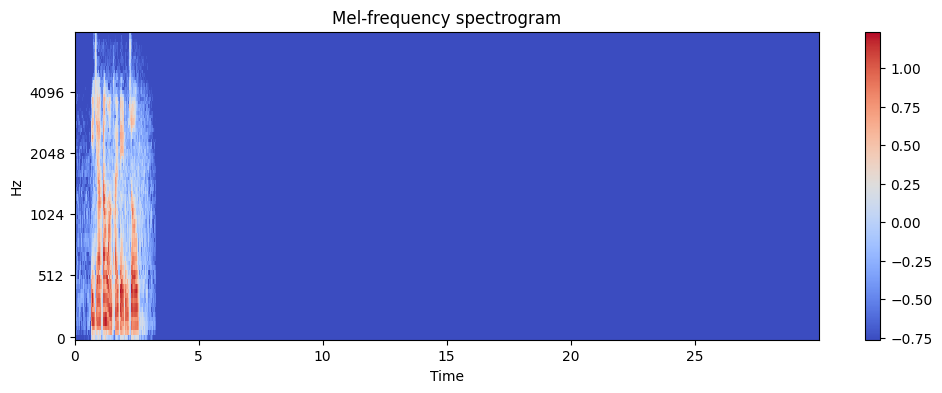

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa.display


example_input_features = hf_train_data[0]['input_features']

plt.figure(figsize=(12, 4))

librosa.display.specshow(
    np.array(example_input_features),
    x_axis="time",
    y_axis="mel",
    sr=processor.feature_extractor.sampling_rate,
    hop_length=processor.feature_extractor.hop_length
    )

plt.colorbar()
plt.title("Mel-frequency spectrogram")
plt.show()

In [ ]:
processor.tokenizer.convert_ids_to_tokens(hf_train_data[0]['label'])

['<|startoftranscript|>',
 '<|zh|>',
 '<|transcribe|>',
 '<|notimestamps|>',
 'ä¸Ģ',
 'å®¶',
 'æĲ',
 '¬',
 'å¾Ģ',
 'åı°',
 'åĮĹ',
 'èĺ',
 'Ĩ',
 'æ´²',
 '<|endoftext|>']

In [ ]:
processor.tokenizer.special_tokens_map

{'bos_token': '<|endoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '<|endoftext|>'}

In [ ]:
processor.tokenizer.decode(hf_train_data[0]['label'])

'<|startoftranscript|><|zh|><|transcribe|><|notimestamps|>一家搬往台北蘆洲<|endoftext|>'

In [ ]:
mock_features = [hf_train_data[i] for i in range(4)]
label_batch = [{'input_ids':feature['label']} for feature in mock_features]
print(label_batch)

[{'input_ids': [50258, 50260, 50359, 50363, 2257, 5155, 22220, 105, 29510, 15433, 26668, 31882, 228, 48706, 50257]}, {'input_ids': [50258, 50260, 50359, 50363, 5884, 6404, 9709, 13089, 19847, 23151, 50257]}, {'input_ids': [50258, 50260, 50359, 50363, 16075, 11914, 8244, 9042, 9254, 1546, 36241, 19117, 13352, 254, 20690, 2289, 50257]}, {'input_ids': [50258, 50260, 50359, 50363, 6236, 13740, 235, 13387, 113, 161, 9915, 8244, 8949, 14637, 28899, 50257]}]


In [ ]:
label_batch = processor.tokenizer.pad(label_batch, return_tensors='pt')
print(label_batch)

{'input_ids': tensor([[50258, 50260, 50359, 50363,  2257,  5155, 22220,   105, 29510, 15433,
         26668, 31882,   228, 48706, 50257, 50257, 50257],
        [50258, 50260, 50359, 50363,  5884,  6404,  9709, 13089, 19847, 23151,
         50257, 50257, 50257, 50257, 50257, 50257, 50257],
        [50258, 50260, 50359, 50363, 16075, 11914,  8244,  9042,  9254,  1546,
         36241, 19117, 13352,   254, 20690,  2289, 50257],
        [50258, 50260, 50359, 50363,  6236, 13740,   235, 13387,   113,   161,
          9915,  8244,  8949, 14637, 28899, 50257, 50257]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]])}


In [ ]:
labels = label_batch['input_ids'].masked_fill_(label_batch['attention_mask'].ne(1), -100)
print(labels)

tensor([[50258, 50260, 50359, 50363,  2257,  5155, 22220,   105, 29510, 15433,
         26668, 31882,   228, 48706, 50257,  -100,  -100],
        [50258, 50260, 50359, 50363,  5884,  6404,  9709, 13089, 19847, 23151,
         50257,  -100,  -100,  -100,  -100,  -100,  -100],
        [50258, 50260, 50359, 50363, 16075, 11914,  8244,  9042,  9254,  1546,
         36241, 19117, 13352,   254, 20690,  2289, 50257],
        [50258, 50260, 50359, 50363,  6236, 13740,   235, 13387,   113,   161,
          9915,  8244,  8949, 14637, 28899, 50257,  -100]])


In [ ]:
import torch
from dataclasses import dataclass
from typing import Any, List, Dict, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> List[Dict[str, torch.Tensor]]:
        input_features = [{'input_features': feature['input_features']} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors = 'pt')

        label_features = [{'input_ids': feature['label']} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors = 'pt')
        labels = labels_batch['input_ids'].masked_fill_(labels_batch['attention_mask'].ne(1), -100)

        batch['labels'] = labels

        return batch

In [ ]:
import gc
from datasets import load_from_disk

BASE_SAVE_DIR = Path('/content/processed_cv_datasets')
HF_TRAIN_DIR = BASE_SAVE_DIR / 'hf_train'

hf_train_data.save_to_disk(HF_TRAIN_DIR)

del hf_train_data
gc.collect()

hf_train_data = load_from_disk(HF_TRAIN_DIR)

Saving the dataset (0/15 shards):   0%|          | 0/7369 [00:00<?, ? examples/s]

In [ ]:
HF_DEV_DIR = BASE_SAVE_DIR / 'hf_dev'
HF_TEST_DIR = BASE_SAVE_DIR / 'hf_test'

def process_cv_dataset(tsv_name, clips_dir, map_func, hf_data_dir ):

    # 1. 讀取 TSV 檔案
    df = pd.read_csv(lang_dir / tsv_name, sep='\t')

    # 2. 建立音檔絕對路徑
    df['audio_path'] = df['path'].apply(lambda x: str(clips_dir / x))

    # 3. 轉換為 Hugging Face Dataset
    hf_data = Dataset.from_pandas(df)
    hf_data = hf_data.remove_columns(['path'])

    # 4. 指定音訊採樣率為 16kHz
    hf_data = hf_data.cast_column('audio_path', Audio(sampling_rate=16000))

    # 5. 進行特徵提取與標籤轉換
    hf_data = hf_data.map(map_func, remove_columns=hf_data.column_names)

    hf_data.save_to_disk(hf_data_dir)
    del hf_data
    gc.collect()

    hf_data = load_from_disk(hf_data_dir)

    return hf_data

hf_dev_data = process_cv_dataset('dev.tsv', clips_dir, prepare_dataset, HF_DEV_DIR)
hf_test_data = process_cv_dataset('test.tsv', clips_dir, prepare_dataset, HF_TEST_DIR)

Map:   0%|          | 0/5107 [00:00<?, ? examples/s]

Saving the dataset (0/10 shards):   0%|          | 0/5107 [00:00<?, ? examples/s]

Map:   0%|          | 0/5107 [00:00<?, ? examples/s]

Saving the dataset (0/10 shards):   0%|          | 0/5107 [00:00<?, ? examples/s]

## Evaluation Metric：Character Error Rate (CER)

在中文等無空格分隔的語音轉寫 (ASR) 任務中，通常使用 **字錯誤率 (CER)** 作為主要評估指標。CER 代表模型預測文字與標準答案 (Ground Truth) 之間的差異程度，**數值越低越好**。

$$\text{CER} = \frac{S + D + I}{N} \times 100\%$$

其中各變數代表：
* **$S$ (Substitutions, 替換)**：錯別字或替換錯誤的字數。
* **$D$ (Deletions, 刪除)**：漏轉錄的字數。
* **$I$ (Insertions, 插入)**：多轉錄的冗餘字數。
* **$N$ (Total Characters)**：標準答案 (Ground Truth) 的總字數 ($N = S + D + C$，其中 $C$ 為正確轉寫的字數)。

**例**：
*   **標準答案 (Ground Truth)**：我們 今天 去 吃 晚餐（共 8 個字，$N = 8$）
*   **模型預測 (Prediction)**：我們 明天 吃 晚 飯


---
**變數解析與計算**：

* $N = 8$：標準答案總字數（我、們、今、天、去、吃、晚、餐）。
* $S = 2$ (Substitutions, 替換)：
把「今」聽錯並替換成了「明」（「今天」變成「明天」）。
    1. 把「餐」聽錯並替換成了
    2. 「飯」（「晚餐」變成「晚飯」）。
* $D = 1$ (Deletions, 刪除/漏字)：漏掉了原句中的「去」字。
* $I = 0$ (Insertions, 插入/多字)：此例模型沒有多吐出冗餘的字。


---

**CER 計算結果**：
$$\text{CER} = \frac{S + D + I}{N} = \frac{2 + 1 + 0}{8} = \frac{3}{8} = 37.5\%$$




In [ ]:
!pip install evaluate jiwer
import evaluate

metric = evaluate.load('cer')

def compute_metric(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens = True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens = True)

    cer = 100 * metric.compute(predictions = pred_str, references = label_str)
    return {'cer':cer}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 115.1 MB/s eta 0:00:00


## 模型訓練



### 初始化 Whisper 模型與生成參數配置 (`generation_config`)

載入 `WhisperForConditionalGeneration` 基礎模型，並針對訓練階段與生成設定進行調整：

* **訓練效能設定**：
  * **`use_cache = False`**：訓練時採用 Teacher Forcing 平行計算，關閉 KV 快取以**節省記憶體**並相容**梯度檢查點 (Gradient Checkpointing)**。

* **生成參數對齊與警告消除 (`generation_config`)**：
  * **`language = "zh"` & `task = "transcribe"`**：指定生成語言為中文，並執行語音轉寫任務。
  * **`forced_decoder_ids = None`**：清空舊版前綴 ID 設定，改用新版 API 動態控制解碼前綴。
  * **`suppress_tokens = None` & `begin_suppress_tokens = None`**：清空預設的字符壓制列表，避免訓練過程中傳入自訂 `LogitsProcessor` 時引發參數重複衝突。
  * **`pad_token_id = processor.tokenizer.pad_token_id`**：明確指派 Padding Token ID，確保批次對齊時能正確傳遞 Attention Mask 並消除警告。

In [ ]:
from transformers import WhisperForConditionalGeneration
import torch

model = WhisperForConditionalGeneration.from_pretrained(
    'openai/whisper-large-v2',
    device_map='auto')

# 為了訓練過程順利，關閉 KV Cache (推論時再開啟)
model.config.use_cache = False

# 設定生成時的語言與任務，確保模型知道這是在做中文語音辨識
# 1. 直接指定語言與任務，並清空舊版的 forced_decoder_ids
model.generation_config.language = "zh"
model.generation_config.task = "transcribe"
model.generation_config.forced_decoder_ids = None

# 2. 清空抑制標記設定，避免 LogitsProcessor 衝突
model.generation_config.suppress_tokens = None
model.generation_config.begin_suppress_tokens = None

# 3. 明確指定 pad_token_id 消除 Attention Mask 警告
model.generation_config.pad_token_id = processor.tokenizer.pad_token_id

model.safetensors:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

###  Whisper-large-v2 的輸入與輸出規格

`WhisperForConditionalGeneration` 層級結構概覽：

#### 1. WhisperEncoder
* **輸入特徵規格**：`Conv1d(80, 1280, ...)`
  * 輸入通道數為 **80**，代表預處理後傳入的 **80 維度 Log-Mel 聲譜圖 (80 Mel Bins)**。
  * 經過兩層 1D 卷積後，特徵維度投影並擴展至 **1280** 維（隱藏層大小 $d_{\text{model}} = 1280$）。
* **序列長度限制**：`Embedding(1500, 1280)`
  * 位置編碼上限為 **1500**。原始 30 秒音訊對應 3000 個時間影格，經過步長為 2 的 1D 卷積下採樣（Downsampling）後，壓縮為 **1500 個時間影格**傳入 32 層 Encoder。

#### 2. WhisperDecoder
* **詞彙庫大小與 ID**：`Embedding(51865, 1280, padding_idx=50257)`
  * 詞彙庫（Vocab Size）大小為 **51,865** 個 Token。
  * `padding_idx` 指定為 **`50257`**（對應 `<|endoftext|>`），作為批次填充標記。
* **生成長度限制**：`WhisperPositionalEmbedding(448, 1280)`
  * 解碼器單次自回歸生成的最大序列長度限制為 **448** 個 Token。

#### 3. Model Output
* **輸出頭投影**：`proj_out`: `Linear(in_features=1280, out_features=51865, bias=False)`
  * 將 Decoder 輸出的 1280 維特徵投影回 **51,865** 個類別（Vocab Size）。
  * 最終計算每個位置對應到字典中各 Token 的 Logits 機率分佈，用以生成最終的文字序列。

In [ ]:
print(model)

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 1280, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(1280, 1280, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 1280)
      (layers): ModuleList(
        (0-31): 32 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=1280, out_features=1280, bias=False)
            (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
            (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
            (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1280, out_features=5120, bias=True)
          (fc2): Linear(in_features=5120, out_features=1280, bias=Tru

### `LoraConfig`參數配置設定

* **`r` (Rank / 低秩維度)**：
  * **作用**：定義 LoRA 低秩分解矩陣的秩（Rank）。

* **`lora_alpha` (Scaling Factor / 縮放係數)**：
  * **作用**：控制 LoRA 權重對原始模型權重的影響比例（縮放因子通常計算為 $\frac{\text{lora_alpha}}{r}$）。

* **`target_modules` (目標模組)**：
  * **作用**：指定要插入 LoRA 模組的特定模型層名稱（例如 Attention 機制的 Query、Value 投影層）。
  * **可設定**: "q_proj", "k_proj", "v_proj", "out_proj", "encoder_attn.q_proj", "encoder_attn.v_proj" 等
* **`lora_dropout` (Dropout 機率)**：
  * **作用**：在 LoRA 模組的輸入層設定 Dropout 比例。

* **`bias` (偏置項訓練設定)**：
  * **作用**：控制模型中偏置項（Bias）的訓練策略。
  * **常見設定**：
    * `'none'`：完全不訓練偏置項（僅訓練 LoRA 矩陣）。
    * `'all'`：訓練模型中所有的偏置項。
    * `'lora_only'`：僅訓練被 LoRA 覆蓋之模組的偏置項。

In [ ]:
!pip install -q peft "torchao>=0.16.0"

from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(r = 4,
                         lora_alpha = 8,
                         target_modules = ['q_proj', 'v_proj'],
                         lora_dropout = 0.05,
                         bias = 'none')

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.8 MB/s eta 0:00:00


trainable params: 1,966,080 || all params: 1,545,271,040 || trainable%: 0.1272


In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

model_save_dir = '/content/drive/MyDrive/whisper-large-v2-zh-TW-lora-final'

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor
    )

training_args = Seq2SeqTrainingArguments(
    output_dir='whisper-large-v2-zh-TW-lora',

    # core hyper-parameters
    learning_rate=1e-3,
    per_device_train_batch_size=8,
    max_steps=101,
    #label_smoothing_factor=0.01,

    # Seq2Seq task setting
    predict_with_generate=True,
    generation_max_length=128,

    # memory & acceleration
    bf16=True,
    gradient_accumulation_steps=2,

    # evaluation & monitor
    eval_strategy='steps',
    save_strategy='best',
    logging_strategy='steps',
    logging_steps=50,
    report_to='wandb',
    run_name='whisper-lora-run-01',

    # model checkpoint
    load_best_model_at_end=True,
    metric_for_best_model='cer',
    greater_is_better=False,
    save_total_limit=3

)

trainer = Seq2SeqTrainer(
    model=model,
    data_collator=data_collator,
    processing_class=processor,
    args=training_args,
    train_dataset=hf_train_data,
    eval_dataset=hf_dev_data,
    compute_metrics=compute_metric
)

In [ ]:
trainer.train()

trainer.save_model(model_save_dir)
processor.save_pretrained(model_save_dir)

print(f"LoRA 模型與 Processor 已儲存至: {model_save_dir}")

In [ ]:
# 評估測試集
test_results = trainer.evaluate(hf_test_data)

print(f"Test CER: {test_results['eval_cer']:.2f}%")

Test CER: 7.20%


In [ ]:
from peft import PeftModel, PeftConfig
from transformers import WhisperForConditionalGeneration, WhisperProcessor


#  載入剛存下來的 Processor
processor = WhisperProcessor.from_pretrained(model_save_dir, language="Chinese", task="transcribe")

#  載入原始的 Whisper-large-v2 基礎模型
base_model = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-large-v2",
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# 將 LoRA 權重載入到基礎模型中
peft_model = PeftModel.from_pretrained(base_model, model_save_dir)
peft_model.eval()

# 讀取並處理音檔
sample_df = df_test.sample(n=5)

for index, row in sample_df.iterrows():
    audio_path = str(clips_dir / row['path'])
    audio_decoder = Audio(sampling_rate=16000)
    decoded_audio = audio_decoder.decode_example({
        "path": audio_path,
        'bytes': None
        })
    audio_array = decoded_audio['array']

    # 提取特徵並轉到 GPU
    inputs = processor(
        audio_array,
        sampling_rate=16000,
        return_tensors="pt"
    ).to("cuda", dtype=torch.bfloat16)

    forced_decoder_ids = processor.tokenizer.get_decoder_prompt_ids(language="zh", task="transcribe")

    # 進行生成
    with torch.no_grad():
        with peft_model.disable_adapter():
            base_model_generated_ids = peft_model.generate(
                **inputs,
                forced_decoder_ids=forced_decoder_ids,
                max_new_tokens=128
            )

        peft_model_generated_ids = peft_model.generate(
            **inputs,
            forced_decoder_ids=forced_decoder_ids,
            max_new_tokens=128
        )

    # 解碼輸出文字
    base_model_generated_ids_transcription = processor.decode(base_model_generated_ids, skip_special_tokens=True)[0]
    peft_model_generated_ids_transcription = processor.decode(peft_model_generated_ids, skip_special_tokens=True)[0]
    # 顯示播放介面與推論結果
    print("=" * 70)

    ipd.display(ipd.Audio(filename=audio_path))

    # 在播放器下方顯示模型推論的文字
    print(f"Base Model Prediction: {base_model_generated_ids_transcription}\n")
    print(f"PEFT Model Prediction: {peft_model_generated_ids_transcription}\n")

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformer

Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Base Model Prediction: 本來以為會有點詭異

PEFT Model Prediction: 本來以為會有點詭異



Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Base Model Prediction: 天龍八部

PEFT Model Prediction: 天龍八部



Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Base Model Prediction: 媽媽,是我

PEFT Model Prediction: 媽媽是我

